# Definição - Palavras Chave

Dado um texto, iremos utilizar essas funções para saber a intensidade e a positividade/negatividade do texto.

In [ ]:
palavras_chave_positivas = [
  'ótimo', 
  'excelente', 
  'incrível',
  'fantástico',
  'maravilhoso',
  'feliz',
  'surpreendente',
  'bom'
]

palavras_chave_negativas = [
  'ruim',
  'péssimo',
  'horrível',
  'terrível',
  'desagradável',
  'decepcionante',
  'triste',
  'frustrante'
]

palavras_chave_intensificadoras = [
  'muito',
  'bastante',
  'extremamente',
  'incrivelmente',
  'realmente',
  'completamente'
]

palavras_chave_negacoes = [
  'não',
  'jamais',
  'nenhum',
  'nem',
  'nada'
]

def calcular_fp(txt: str) -> float:
  palavras = txt.split(' ')
  freq_palavras_pos = len([p for p in palavras if p.lower() in palavras_chave_positivas])
  freq_palavras_neg = len([p for p in palavras if p.lower() in palavras_chave_negativas])
  freq_palavras_negacao = len([p for p in palavras if p.lower() in palavras_chave_negacoes])
  total_palavras = len(palavras)
  
  return (freq_palavras_pos - freq_palavras_negacao) / total_palavras

def calcular_fn(txt: str) -> float:
  palavras = txt.split(' ')
  freq_palavras_pos = len([p for p in palavras if p.lower() in palavras_chave_positivas])
  freq_palavras_neg = len([p for p in palavras if p.lower() in palavras_chave_negativas])
  freq_palavras_negacao = len([p for p in palavras if p.lower() in palavras_chave_negacoes])
  total_palavras = len(palavras)

  return (freq_palavras_neg - freq_palavras_negacao) / total_palavras

def calcular_intensidade(txt: str) -> float:
  palavras = txt.split(' ')
  freq_palavras_inten = len([p for p in palavras if p.lower() in palavras_chave_intensificadoras])
  total_palavras = len(palavras)
  
  return freq_palavras_inten / total_palavras

# Definição - Fuzzy

In [193]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

positividade = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Positividade')
negatividade = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Negatividade')
intensidade = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Intensidade')
polaridade = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'Polaridade')

positividade['Baixa'] = fuzz.trimf(positividade.universe, [0, 0, 0.3])
positividade['Média'] = fuzz.trimf(positividade.universe, [0.2, 0.4, 0.6])
positividade['Alta'] = fuzz.trimf(positividade.universe, [0.4, 1, 1])

negatividade['Baixa'] = fuzz.trimf(negatividade.universe, [0, 0, 0.3])
negatividade['Média'] = fuzz.trimf(negatividade.universe, [0.2, 0.4, 0.6])
negatividade['Alta'] = fuzz.trimf(negatividade.universe, [0.4, 1, 1])

intensidade['Baixa'] = fuzz.trimf(intensidade.universe, [0, 0, 0.3])
intensidade['Média'] = fuzz.trimf(intensidade.universe, [0.2, 0.4, 0.6])
intensidade['Alta'] = fuzz.trimf(intensidade.universe, [0.4, 1, 1])

polaridade['Negativa'] = fuzz.trimf(polaridade.universe, [0, 0, 0.3])
polaridade['Neutra'] = fuzz.trimf(polaridade.universe, [0.2, 0.4, 0.6])
polaridade['Positiva'] = fuzz.trimf(polaridade.universe, [0.4, 1, 1])

## Gráficos

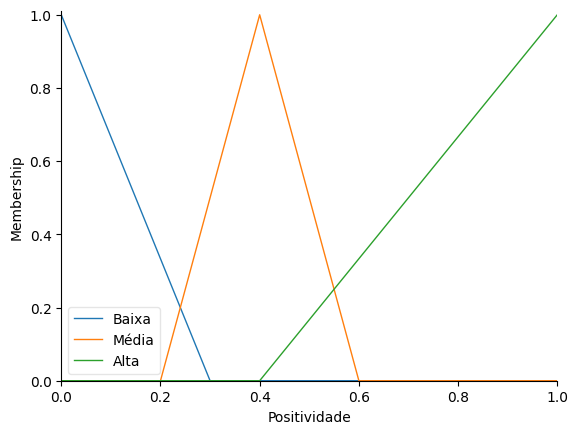

In [194]:
positividade.view()

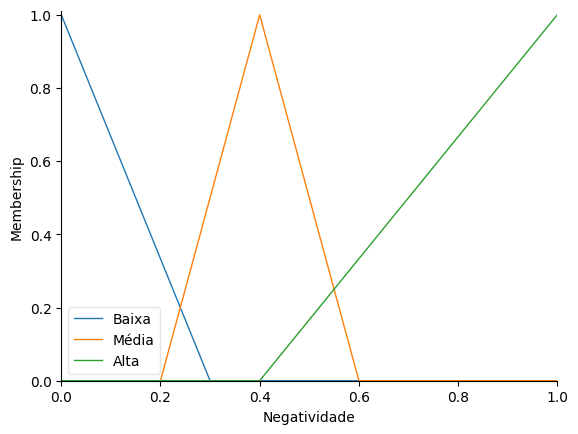

In [195]:
negatividade.view()

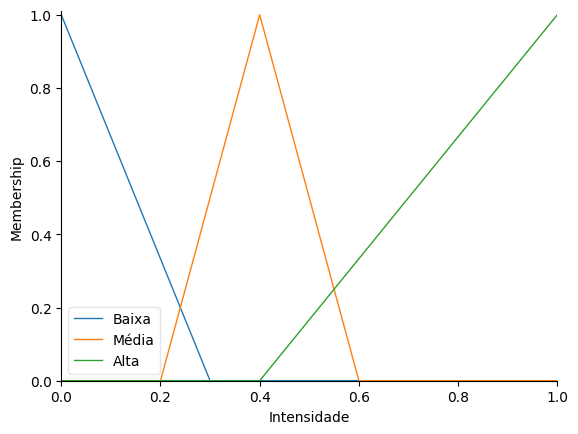

In [196]:
intensidade.view()

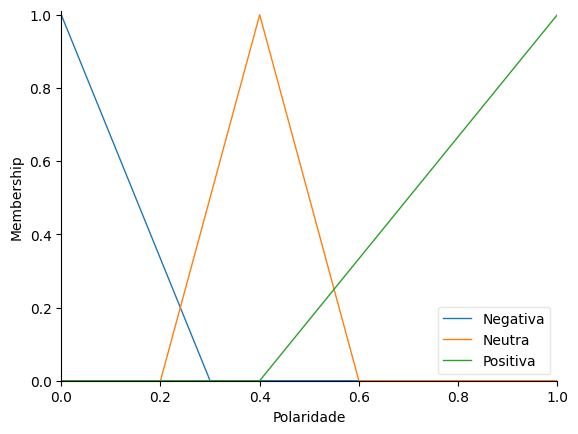

In [197]:
polaridade.view()

# Regras

In [ ]:
# Se aprox X e dist Y, então freio Z

rule1 = ctrl.Rule(positividade['Alta'] & intensidade['Alta'] & negatividade['Baixa'], polaridade['Positiva'])
rule2 = ctrl.Rule(positividade['Média'] & intensidade['Média'] & negatividade['Média'], polaridade['Neutra'])
rule3 = ctrl.Rule(positividade['Baixa'] & positividade['Baixa'] & negatividade['Alta'], polaridade['Negativa'])
rule4 = ctrl.Rule(positividade['Alta'] | negatividade['Baixa'], polaridade['Positiva'])
rule5 = ctrl.Rule(positividade['Baixa'] | negatividade['Alta'], polaridade['Negativa'])
rule6 = ctrl.Rule(positividade['Baixa'] & negatividade['Baixa'] & intensidade['Baixa'], polaridade['Neutra'])

# Simulação

In [276]:
sentimento_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6])
sentimento_simulador = ctrl.ControlSystemSimulation(sentimento_ctrl)

texto = 'Bom Ruim Ruim'

print(f'Positivo: {calcular_fp(texto)}')
print(f'Negativo: {calcular_fn(texto)}')
print(f'Intensidade: {calcular_intensidade(texto)}')

sentimento_simulador.input['Positividade'] = calcular_fp(texto)
sentimento_simulador.input['Negatividade'] = calcular_fn(texto)
sentimento_simulador.input['Intensidade'] = calcular_intensidade(texto)

sentimento_simulador.compute()
print(f'Polaridade: {sentimento_simulador.output['Polaridade']}')

Positivo: 0.3333333333333333
Negativo: 0.6666666666666666
Intensidade: 0.0
Polaridade: 0.11984126984126983


## Gráficos

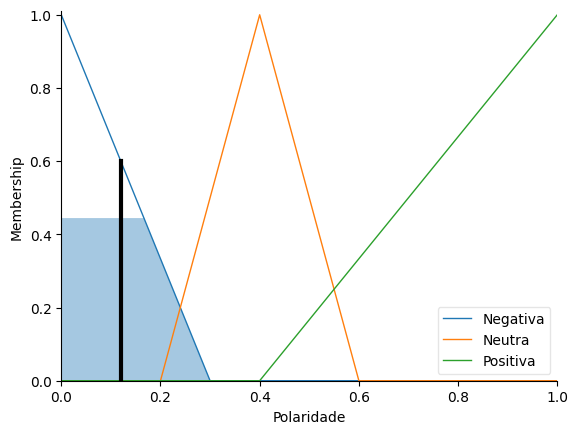

In [277]:
polaridade.view(sim=sentimento_simulador)